In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error

# Display plots inside Jupyter Notebook
%matplotlib inline

In [2]:
df = pd.read_excel("Production_Data.xlsx", skiprows=[1])

df.head()

,Month,Liquid Rate,Oil Rate,Water Cut,GOR
0,1,1402,1402,0,151
1,2,1248,1248,0,154
2,3,1204,1204,0,154
3,4,1131,1131,0,161
4,5,1055,1055,0,167


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Month        27 non-null     int64
 1   Liquid Rate  27 non-null     int64
 2   Oil Rate     27 non-null     int64
 3   Water Cut    27 non-null     int64
 4   GOR          27 non-null     int64
dtypes: int64(5)
memory usage: 1.2 KB


In [4]:
df.describe()

,Month,Liquid Rate,Oil Rate,Water Cut,GOR
count,27.000000,27.000000,27.000000,27.000000,27.000000
mean,14.000000,749.370370,692.666667,10.333333,157.407407
std,7.937254,269.263118,311.734848,9.841044,47.147281
min,1.000000,454.000000,342.000000,0.000000,85.000000
25%,7.500000,593.500000,470.000000,0.000000,127.500000
50%,14.000000,637.000000,605.000000,6.000000,142.000000
75%,20.500000,908.000000,908.000000,22.500000,174.000000
max,27.000000,1402.000000,1402.000000,25.000000,266.000000


In [5]:
df.isnull().sum()

Month          0
Liquid Rate    0
Oil Rate       0
Water Cut      0
GOR            0
dtype: int64

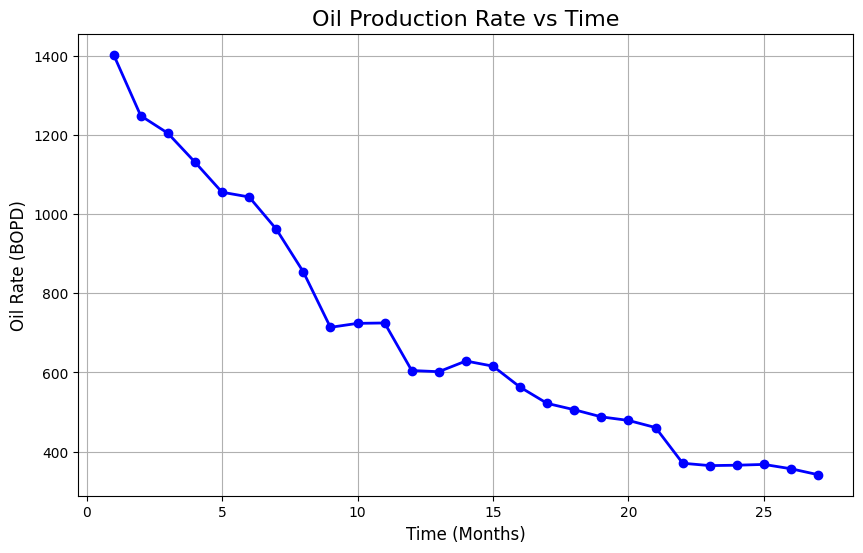

In [6]:
plt.figure(figsize=(10,6))

plt.plot(df["Month"],
         df["Oil Rate"],
         marker='o',
         color='blue',
         linewidth=2)

plt.title("Oil Production Rate vs Time", fontsize=16)

plt.xlabel("Time (Months)", fontsize=12)
plt.ylabel("Oil Rate (BOPD)", fontsize=12)

plt.grid(True)

plt.show()

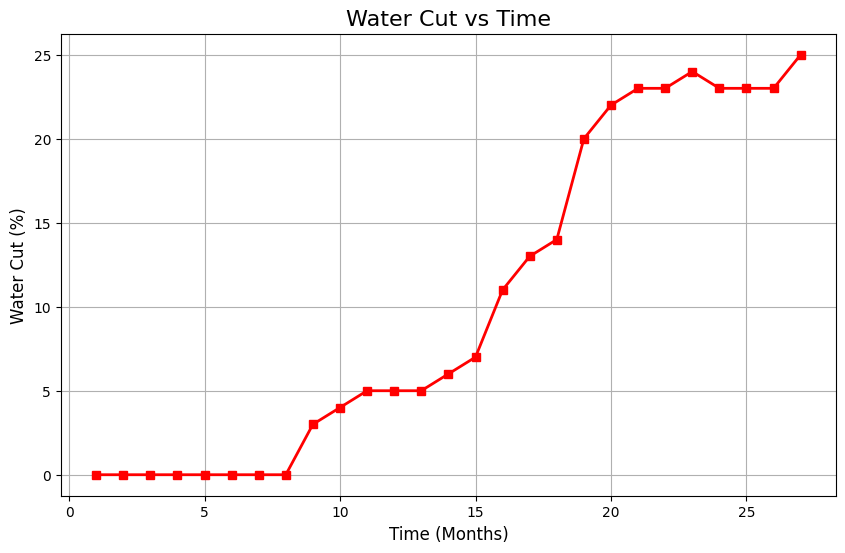

In [7]:
plt.figure(figsize=(10,6))

plt.plot(df["Month"],
         df["Water Cut"],
         marker='s',
         color='red',
         linewidth=2)

plt.title("Water Cut vs Time", fontsize=16)
plt.xlabel("Time (Months)", fontsize=12)
plt.ylabel("Water Cut (%)", fontsize=12)

plt.grid(True)

plt.show()

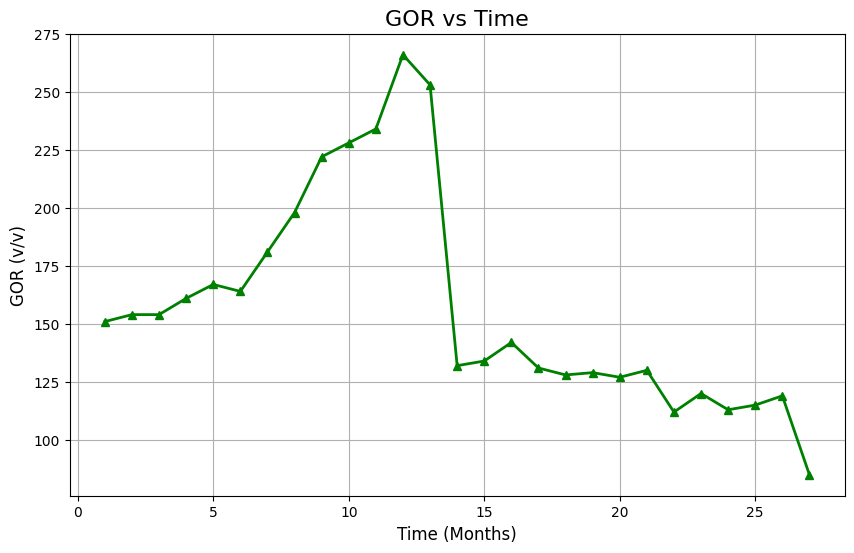

In [8]:
plt.figure(figsize=(10,6))

plt.plot(df["Month"],
         df["GOR"],
         marker='^',
         color='green',
         linewidth=2)

plt.title("GOR vs Time", fontsize=16)
plt.xlabel("Time (Months)", fontsize=12)
plt.ylabel("GOR (v/v)", fontsize=12)

plt.grid(True)

plt.show()

In [9]:
# Independent variable (time)
t = df["Month"].values

# Dependent variable (oil production rate)
q = df["Oil Rate"].values

print("Time (Months):")
print(t)

print("\nOil Rate (BOPD):")
print(q)

Time (Months):
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27]

Oil Rate (BOPD):
[1402 1248 1204 1131 1055 1043  962  854  714  724  725  605  602  629
  616  563  522  506  488  479  461  371  365  366  368  357  342]


In [10]:
# Exponential Decline Model
def exponential_decline(t, qi, Di):
    """
    Arps Exponential Decline Model

    Parameters:
    t  : Time (months)
    qi : Initial oil production rate (BOPD)
    Di : Initial decline rate (1/month)

    Returns:
    Predicted oil production rate
    """
    return qi * np.exp(-Di * t)

In [11]:
# Initial guess for qi and Di
initial_guess = [1402, 0.05]

# Fit exponential decline model
params_exp, covariance_exp = curve_fit(
    exponential_decline,
    t,
    q,
    p0=initial_guess
)

# Extract fitted parameters
qi_exp, Di_exp = params_exp

print("Exponential Decline Parameters")
print("--------------------------------")
print(f"Initial Production Rate (qi) = {qi_exp:.2f} BOPD")
print(f"Initial Decline Rate (Di)    = {Di_exp:.6f} per month")

Exponential Decline Parameters
--------------------------------
Initial Production Rate (qi) = 1413.69 BOPD
Initial Decline Rate (Di)    = 0.058460 per month


In [12]:
q_exp = exponential_decline(t, qi_exp, Di_exp)

In [13]:
# Display actual and predicted values
comparison = pd.DataFrame({
    "Month": t,
    "Actual_Oil_Rate": q,
    "Predicted_Exponential": q_exp
})

comparison.head(10)

,Month,Actual_Oil_Rate,Predicted_Exponential
0,1,1402,1333.415811
1,2,1248,1257.699244
2,3,1204,1186.282160
3,4,1131,1118.920417
4,5,1055,1055.383738
5,6,1043,995.454920
6,7,962,938.929095
7,8,854,885.613028
8,9,714,835.324455
9,10,724,787.891464


In [14]:
comparison["Predicted_Exponential"] = comparison["Predicted_Exponential"].round(2)

comparison.head(10)

,Month,Actual_Oil_Rate,Predicted_Exponential
0,1,1402,1333.42
1,2,1248,1257.70
2,3,1204,1186.28
3,4,1131,1118.92
4,5,1055,1055.38
5,6,1043,995.45
6,7,962,938.93
7,8,854,885.61
8,9,714,835.32
9,10,724,787.89


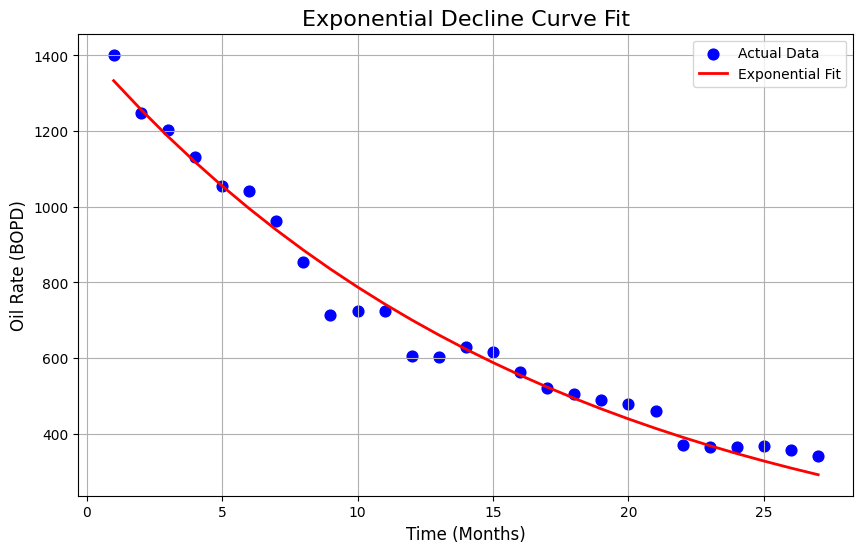

In [15]:
plt.figure(figsize=(10,6))

# Actual production data
plt.scatter(t, q,
            color='blue',
            label='Actual Data',
            s=60)

# Exponential fit
plt.plot(t, q_exp,
         color='red',
         linewidth=2,
         label='Exponential Fit')

plt.title("Exponential Decline Curve Fit", fontsize=16)
plt.xlabel("Time (Months)", fontsize=12)
plt.ylabel("Oil Rate (BOPD)", fontsize=12)

plt.legend()
plt.grid(True)

plt.show()

In [16]:
# Calculate R²
r2_exp = r2_score(q, q_exp)

# Calculate RMSE
rmse_exp = np.sqrt(mean_squared_error(q, q_exp))

print("Exponential Model Performance")
print("-----------------------------")
print(f"R²   = {r2_exp:.4f}")
print(f"RMSE = {rmse_exp:.2f} BOPD")

Exponential Model Performance
-----------------------------
R²   = 0.9789
RMSE = 44.46 BOPD


In [17]:
# Hyperbolic Decline Model
def hyperbolic_decline(t, qi, Di, b):
    """
    Arps Hyperbolic Decline Model

    Parameters:
    t  : Time (months)
    qi : Initial oil production rate (BOPD)
    Di : Initial decline rate (1/month)
    b  : Hyperbolic decline exponent

    Returns:
    Predicted oil production rate
    """
    return qi / ((1 + b * Di * t) ** (1 / b))

In [18]:
# Initial guess
initial_guess = [1402, 0.05, 0.5]

# Fit Hyperbolic Decline Model
params_hyp, covariance_hyp = curve_fit(
    hyperbolic_decline,
    t,
    q,
    p0=initial_guess,
    bounds=([0, 0, 0], [np.inf, np.inf, 2])
)

# Extract fitted parameters
qi_hyp, Di_hyp, b_hyp = params_hyp

print("Hyperbolic Decline Parameters")
print("--------------------------------")
print(f"Initial Production Rate (qi) = {qi_hyp:.2f} BOPD")
print(f"Initial Decline Rate (Di)    = {Di_hyp:.6f} per month")
print(f"Decline Exponent (b)         = {b_hyp:.4f}")

Hyperbolic Decline Parameters
--------------------------------
Initial Production Rate (qi) = 1514.08 BOPD
Initial Decline Rate (Di)    = 0.082168 per month
Decline Exponent (b)         = 0.4800


In [19]:
# Predicted oil rates using Hyperbolic model
q_hyp = hyperbolic_decline(t, qi_hyp, Di_hyp, b_hyp)

In [20]:
comparison["Predicted_Hyperbolic"] = q_hyp.round(2)

comparison.head(10)

,Month,Actual_Oil_Rate,Predicted_Exponential,Predicted_Hyperbolic
0,1,1402,1333.42,1396.85
1,2,1248,1257.70,1292.57
2,3,1204,1186.28,1199.41
3,4,1131,1118.92,1115.86
4,5,1055,1055.38,1040.64
5,6,1043,995.45,972.69
6,7,962,938.93,911.10
7,8,854,885.61,855.12
8,9,714,835.32,804.08
9,10,724,787.89,757.42


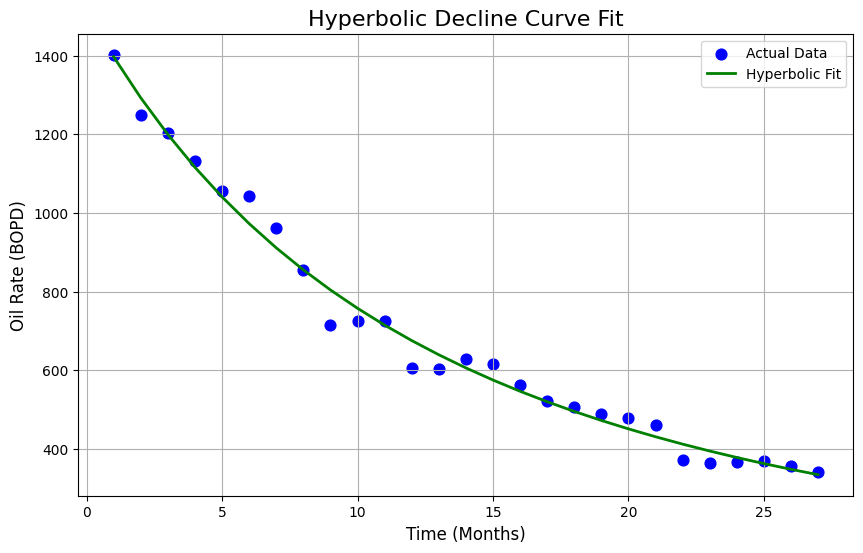

In [21]:
plt.figure(figsize=(10,6))

# Actual production data
plt.scatter(t, q,
            color='blue',
            s=60,
            label='Actual Data')

# Hyperbolic fit
plt.plot(t, q_hyp,
         color='green',
         linewidth=2,
         label='Hyperbolic Fit')

plt.title("Hyperbolic Decline Curve Fit", fontsize=16)
plt.xlabel("Time (Months)", fontsize=12)
plt.ylabel("Oil Rate (BOPD)", fontsize=12)

plt.legend()
plt.grid(True)

plt.show()

In [22]:
# Calculate R²
r2_hyp = r2_score(q, q_hyp)

# Calculate RMSE
rmse_hyp = np.sqrt(mean_squared_error(q, q_hyp))

print("Hyperbolic Model Performance")
print("-----------------------------")
print(f"R²   = {r2_hyp:.4f}")
print(f"RMSE = {rmse_hyp:.2f} BOPD")

Hyperbolic Model Performance
-----------------------------
R²   = 0.9869
RMSE = 35.03 BOPD


In [23]:
# Harmonic Decline Model
def harmonic_decline(t, qi, Di):
    """
    Arps Harmonic Decline Model

    Parameters:
    t  : Time (months)
    qi : Initial oil production rate (BOPD)
    Di : Initial decline rate (1/month)

    Returns:
    Predicted oil production rate
    """
    return qi / (1 + Di * t)

In [24]:
# Initial guess
initial_guess = [1402, 0.05]

# Fit Harmonic Decline Model
params_har, covariance_har = curve_fit(
    harmonic_decline,
    t,
    q,
    p0=initial_guess
)

# Extract parameters
qi_har, Di_har = params_har

print("Harmonic Decline Parameters")
print("---------------------------")
print(f"Initial Production Rate (qi) = {qi_har:.2f} BOPD")
print(f"Initial Decline Rate (Di)    = {Di_har:.6f} per month")

Harmonic Decline Parameters
---------------------------
Initial Production Rate (qi) = 1629.94 BOPD
Initial Decline Rate (Di)    = 0.122717 per month


In [25]:
# Predicted oil rates using Harmonic model
q_har = harmonic_decline(t, qi_har, Di_har)

In [26]:
comparison["Predicted_Harmonic"] = q_har.round(2)

comparison.head(10)

,Month,Actual_Oil_Rate,Predicted_Exponential,Predicted_Hyperbolic,Predicted_Harmonic
0,1,1402,1333.42,1396.85,1451.78
1,2,1248,1257.70,1292.57,1308.73
2,3,1204,1186.28,1199.41,1191.35
3,4,1131,1118.92,1115.86,1093.28
4,5,1055,1055.38,1040.64,1010.14
5,6,1043,995.45,972.69,938.74
6,7,962,938.93,911.10,876.78
7,8,854,885.61,855.12,822.48
8,9,714,835.32,804.08,774.52
9,10,724,787.89,757.42,731.84


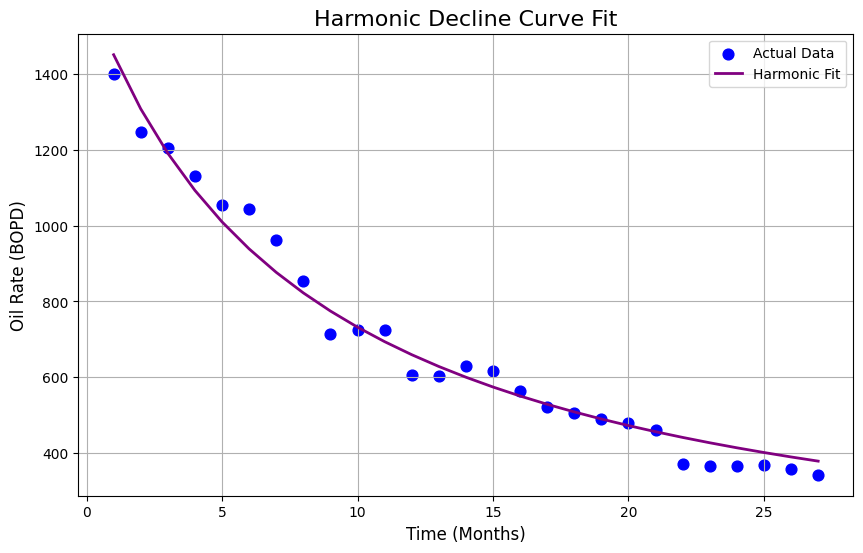

In [27]:
plt.figure(figsize=(10,6))

# Actual production
plt.scatter(t, q,
            color='blue',
            s=60,
            label='Actual Data')

# Harmonic fit
plt.plot(t, q_har,
         color='purple',
         linewidth=2,
         label='Harmonic Fit')

plt.title("Harmonic Decline Curve Fit", fontsize=16)
plt.xlabel("Time (Months)", fontsize=12)
plt.ylabel("Oil Rate (BOPD)", fontsize=12)

plt.legend()
plt.grid(True)

plt.show()

In [28]:
# Calculate R²
r2_har = r2_score(q, q_har)

# Calculate RMSE
rmse_har = np.sqrt(mean_squared_error(q, q_har))

print("Harmonic Model Performance")
print("--------------------------")
print(f"R²   = {r2_har:.4f}")
print(f"RMSE = {rmse_har:.2f} BOPD")

Harmonic Model Performance
--------------------------
R²   = 0.9785
RMSE = 44.87 BOPD


In [29]:
# Final Model Comparison Table

results = pd.DataFrame({
    "Model": ["Exponential", "Hyperbolic", "Harmonic"],
    "qi (BOPD)": [qi_exp, qi_hyp, qi_har],
    "Di (/month)": [Di_exp, Di_hyp, Di_har],
    "b": [0, b_hyp, 1],
    "R²": [r2_exp, r2_hyp, r2_har],
    "RMSE (BOPD)": [rmse_exp, rmse_hyp, rmse_har]
})

# Round values
results = results.round({
    "qi (BOPD)": 2,
    "Di (/month)": 6,
    "b": 4,
    "R²": 4,
    "RMSE (BOPD)": 2
})

print("Final Model Comparison")

display(
    results.style
    .highlight_max(subset=["R²"], color="lightgreen")
    .highlight_min(subset=["RMSE (BOPD)"], color="lightgreen")
)

Final Model Comparison


,Model,qi (BOPD),Di (/month),b,R²,RMSE (BOPD)
0,Exponential,1413.690000,0.058460,0.000000,0.978900,44.460000
1,Hyperbolic,1514.080000,0.082168,0.480000,0.986900,35.030000
2,Harmonic,1629.940000,0.122717,1.000000,0.978500,44.870000


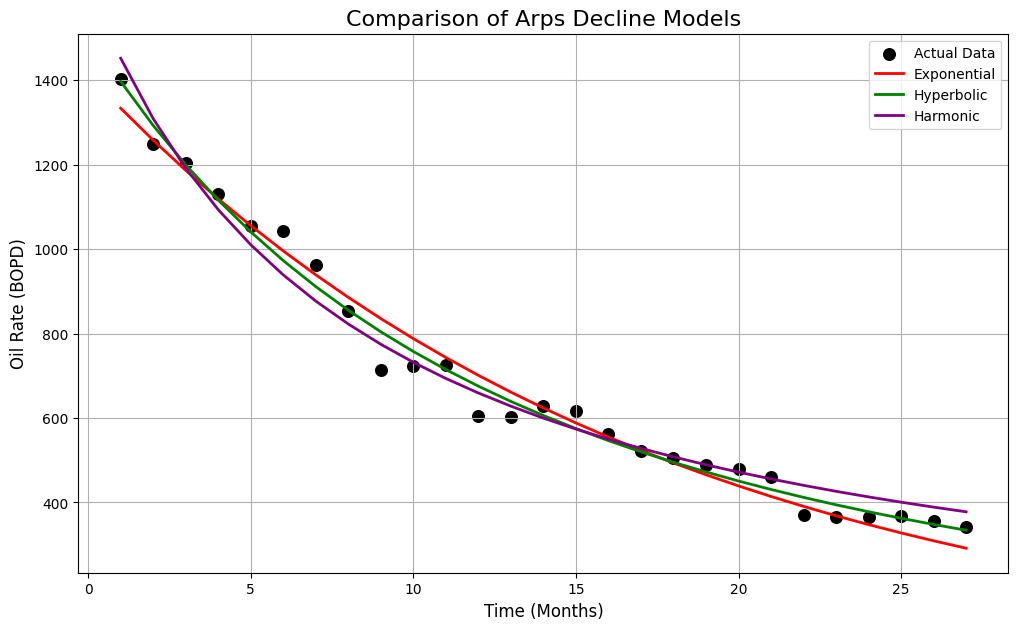

In [30]:
plt.figure(figsize=(12,7))

# Actual production
plt.scatter(t, q,
            color='black',
            s=70,
            label='Actual Data')

# Exponential
plt.plot(t, q_exp,
         color='red',
         linewidth=2,
         label='Exponential')

# Hyperbolic
plt.plot(t, q_hyp,
         color='green',
         linewidth=2,
         label='Hyperbolic')

# Harmonic
plt.plot(t, q_har,
         color='purple',
         linewidth=2,
         label='Harmonic')

plt.title("Comparison of Arps Decline Models", fontsize=16)
plt.xlabel("Time (Months)", fontsize=12)
plt.ylabel("Oil Rate (BOPD)", fontsize=12)

plt.grid(True)
plt.legend()

plt.show()

In [31]:
# Economic limit (BOPD)
economic_limit = 40

# Start forecasting after the last historical month
forecast_month = int(t[-1]) + 1

forecast_time = []
forecast_rate = []

while True:

    # Hyperbolic forecast
    q_future = hyperbolic_decline(
        forecast_month,
        qi_hyp,
        Di_hyp,
        b_hyp
    )

    # Stop when economic limit is reached
    if q_future <= economic_limit:
        break

    forecast_time.append(forecast_month)
    forecast_rate.append(q_future)

    forecast_month += 1

In [32]:
forecast_df = pd.DataFrame({
    "Month": forecast_time,
    "Forecast_Oil_Rate (BOPD)": np.round(forecast_rate, 2)
})

forecast_df.head(10)

,Month,Forecast_Oil_Rate (BOPD)
0,28,321.36
1,29,309.17
2,30,297.65
3,31,286.75
4,32,276.43
5,33,266.65
6,34,257.38
7,35,248.58
8,36,240.21
9,37,232.25


In [33]:
forecast_df.tail()

,Month,Forecast_Oil_Rate (BOPD)
87,115,42.84
88,116,42.22
89,117,41.60
90,118,41.00
91,119,40.41


In [34]:
# First month below the economic limit

final_month = forecast_month
final_rate = hyperbolic_decline(final_month, qi_hyp, Di_hyp, b_hyp)

print("Economic Limit Reached")
print("----------------------")
print(f"Final Forecast Month : {final_month}")
print(f"Oil Rate             : {final_rate:.2f} BOPD")

Economic Limit Reached
----------------------
Final Forecast Month : 120
Oil Rate             : 39.83 BOPD


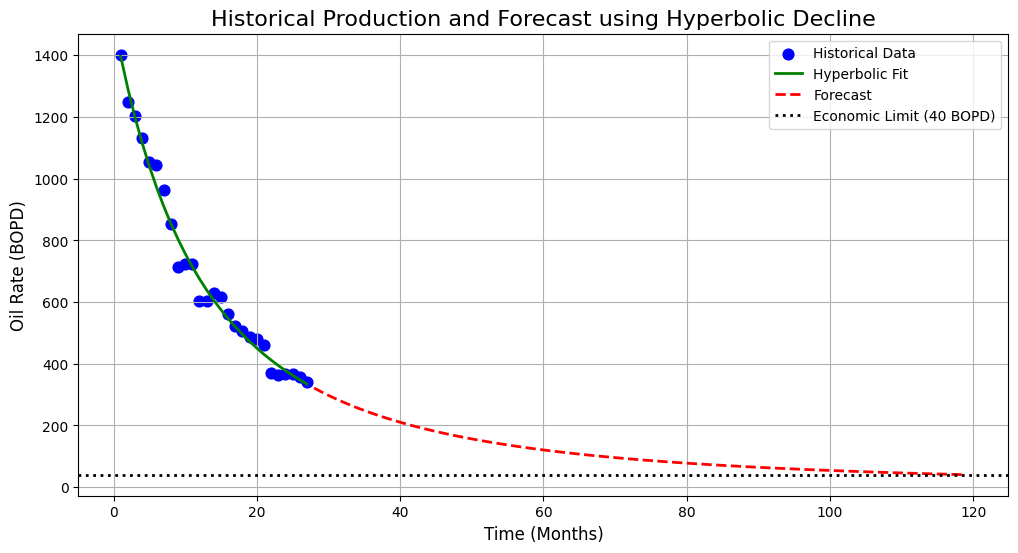

In [35]:
plt.figure(figsize=(12,6))

# Historical production
plt.scatter(
    t,
    q,
    color="blue",
    s=60,
    label="Historical Data"
)

# Hyperbolic fit (history)
plt.plot(
    t,
    q_hyp,
    color="green",
    linewidth=2,
    label="Hyperbolic Fit"
)

# Forecast
plt.plot(
    forecast_time,
    forecast_rate,
    color="red",
    linewidth=2,
    linestyle="--",
    label="Forecast"
)

# Economic limit
plt.axhline(
    y=40,
    color="black",
    linestyle=":",
    linewidth=2,
    label="Economic Limit (40 BOPD)"
)

plt.title("Historical Production and Forecast using Hyperbolic Decline", fontsize=16)
plt.xlabel("Time (Months)", fontsize=12)
plt.ylabel("Oil Rate (BOPD)", fontsize=12)

plt.grid(True)
plt.legend()

plt.show()

In [36]:
# Average days in a month
days_per_month = 30.44

# Monthly oil production (barrels)
df["Monthly_Oil_Production (STB)"] = df["Oil Rate"] * days_per_month

df.head()

,Month,Liquid Rate,Oil Rate,Water Cut,GOR,Monthly_Oil_Production (STB)
0,1,1402,1402,0,151,42676.88
1,2,1248,1248,0,154,37989.12
2,3,1204,1204,0,154,36649.76
3,4,1131,1131,0,161,34427.64
4,5,1055,1055,0,167,32114.20


In [37]:
# Cumulative oil production
df["Cumulative_Oil_Production (STB)"] = df["Monthly_Oil_Production (STB)"].cumsum()

df.head(10)

,Month,Liquid Rate,Oil Rate,Water Cut,GOR,Monthly_Oil_Production (STB),Cumulative_Oil_Production (STB)
0,1,1402,1402,0,151,42676.88,42676.88
1,2,1248,1248,0,154,37989.12,80666.00
2,3,1204,1204,0,154,36649.76,117315.76
3,4,1131,1131,0,161,34427.64,151743.40
4,5,1055,1055,0,167,32114.20,183857.60
5,6,1043,1043,0,164,31748.92,215606.52
6,7,962,962,0,181,29283.28,244889.80
7,8,854,854,0,198,25995.76,270885.56
8,9,735,714,3,222,21734.16,292619.72
9,10,751,724,4,228,22038.56,314658.28


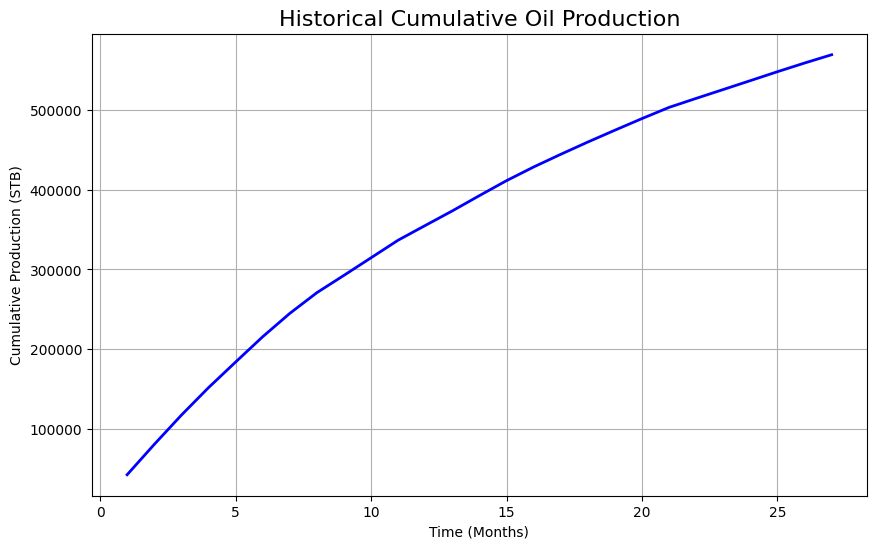

In [38]:
plt.figure(figsize=(10,6))

plt.plot(
    df["Month"],
    df["Cumulative_Oil_Production (STB)"],
    color="blue",
    linewidth=2
)

plt.title("Historical Cumulative Oil Production", fontsize=16)
plt.xlabel("Time (Months)")
plt.ylabel("Cumulative Production (STB)")

plt.grid(True)

plt.show()

In [39]:
# Monthly forecast oil production (STB)

forecast_df["Monthly_Oil_Production (STB)"] = (
    forecast_df["Forecast_Oil_Rate (BOPD)"] * days_per_month
)

forecast_df.head()

,Month,Forecast_Oil_Rate (BOPD),Monthly_Oil_Production (STB)
0,28,321.36,9782.1984
1,29,309.17,9411.1348
2,30,297.65,9060.4660
3,31,286.75,8728.6700
4,32,276.43,8414.5292


In [40]:
# Last historical cumulative production
last_cum = df["Cumulative_Oil_Production (STB)"].iloc[-1]

# Forecast cumulative production
forecast_df["Cumulative_Oil_Production (STB)"] = (
    forecast_df["Monthly_Oil_Production (STB)"].cumsum() + last_cum
)

forecast_df.head()

,Month,Forecast_Oil_Rate (BOPD),Monthly_Oil_Production (STB),Cumulative_Oil_Production (STB)
0,28,321.36,9782.1984,579071.0784
1,29,309.17,9411.1348,588482.2132
2,30,297.65,9060.4660,597542.6792
3,31,286.75,8728.6700,606271.3492
4,32,276.43,8414.5292,614685.8784


In [41]:
forecast_df.tail()

,Month,Forecast_Oil_Rate (BOPD),Monthly_Oil_Production (STB),Cumulative_Oil_Production (STB)
87,115,42.84,1304.0496,887686.4096
88,116,42.22,1285.1768,888971.5864
89,117,41.60,1266.3040,890237.8904
90,118,41.00,1248.0400,891485.9304
91,119,40.41,1230.0804,892716.0108


In [42]:
ultimate_recovery = forecast_df["Cumulative_Oil_Production (STB)"].iloc[-1]

print("Ultimate Recovery Summary")
print("-------------------------")
print(f"Historical Production Period : {int(df['Month'].iloc[-1])} months")
print(f"Forecast Production Period   : {int(forecast_df['Month'].iloc[-1])} months")
print(f"Economic Limit               : 40 BOPD")
print(f"Estimated Ultimate Recovery  : {ultimate_recovery:,.2f} STB")

Ultimate Recovery Summary
-------------------------
Historical Production Period : 27 months
Forecast Production Period   : 119 months
Economic Limit               : 40 BOPD
Estimated Ultimate Recovery  : 892,716.01 STB


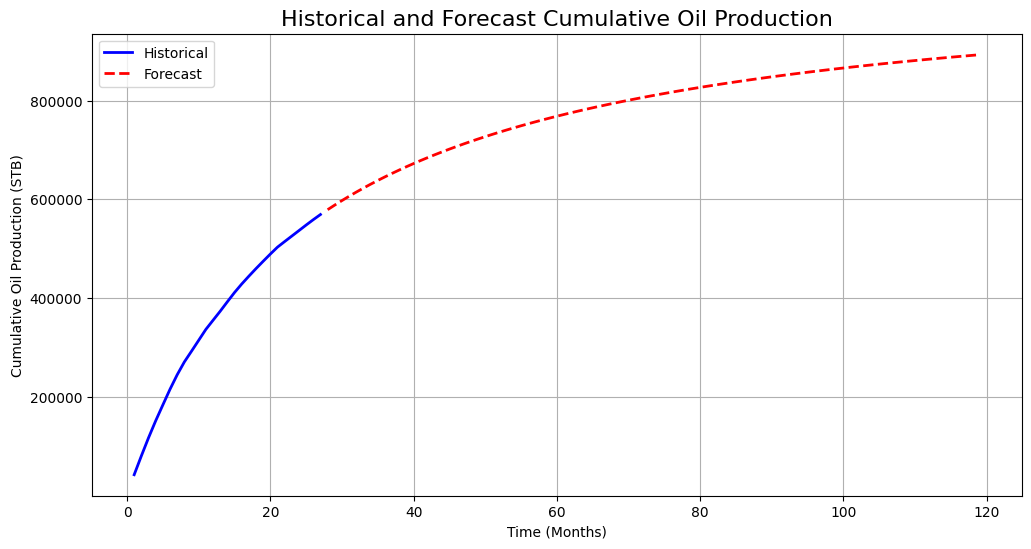

In [43]:
plt.figure(figsize=(12,6))

# Historical cumulative
plt.plot(
    df["Month"],
    df["Cumulative_Oil_Production (STB)"],
    color="blue",
    linewidth=2,
    label="Historical"
)

# Forecast cumulative
plt.plot(
    forecast_df["Month"],
    forecast_df["Cumulative_Oil_Production (STB)"],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Forecast"
)

plt.title("Historical and Forecast Cumulative Oil Production", fontsize=16)
plt.xlabel("Time (Months)")
plt.ylabel("Cumulative Oil Production (STB)")
plt.grid(True)
plt.legend()

plt.show()

In [44]:
# Historical data
history = pd.DataFrame({
    "Month": df["Month"],
    "Oil_Rate": df["Oil Rate"]
})

# Forecast data
future = pd.DataFrame({
    "Month": forecast_df["Month"],
    "Oil_Rate": forecast_df["Forecast_Oil_Rate (BOPD)"]
})

# Combine both
combined = pd.concat([history, future], ignore_index=True)

combined.head()

,Month,Oil_Rate
0,1,1402.0
1,2,1248.0
2,3,1204.0
3,4,1131.0
4,5,1055.0


In [45]:
combined["Year"] = ((combined["Month"] - 1) // 12) + 1

combined.head(15)

,Month,Oil_Rate,Year
0,1,1402.0,1
1,2,1248.0,1
2,3,1204.0,1
3,4,1131.0,1
4,5,1055.0,1
5,6,1043.0,1
6,7,962.0,1
7,8,854.0,1
8,9,714.0,1
9,10,724.0,1


In [46]:
combined["Monthly_Production (STB)"] = (
    combined["Oil_Rate"] * days_per_month
)

In [47]:
yearly_summary = combined.groupby("Year").agg(
    Average_Oil_Rate=("Oil_Rate", "mean"),
    Yearly_Production=("Monthly_Production (STB)", "sum")
)

In [48]:
yearly_summary["Yearly_Cumulative_Production"] = (
    yearly_summary["Yearly_Production"].cumsum()
)

In [49]:
yearly_summary = yearly_summary.round({
    "Average_Oil_Rate": 2,
    "Yearly_Production": 2,
    "Yearly_Cumulative_Production": 2
})

print("Yearly Production Summary")

display(yearly_summary)

Yearly Production Summary


,Average_Oil_Rate,Yearly_Production,Yearly_Cumulative_Production
Year,,,
1,972.25,355143.48,355143.48
2,497.33,181665.92,536809.40
3,297.60,108706.72,645516.12
4,196.39,71735.82,717251.94
5,139.56,50978.78,768230.72
6,104.10,38026.56,806257.28
7,80.53,29414.48,835671.76
8,64.08,23406.23,859077.98
9,52.16,19052.09,878130.08


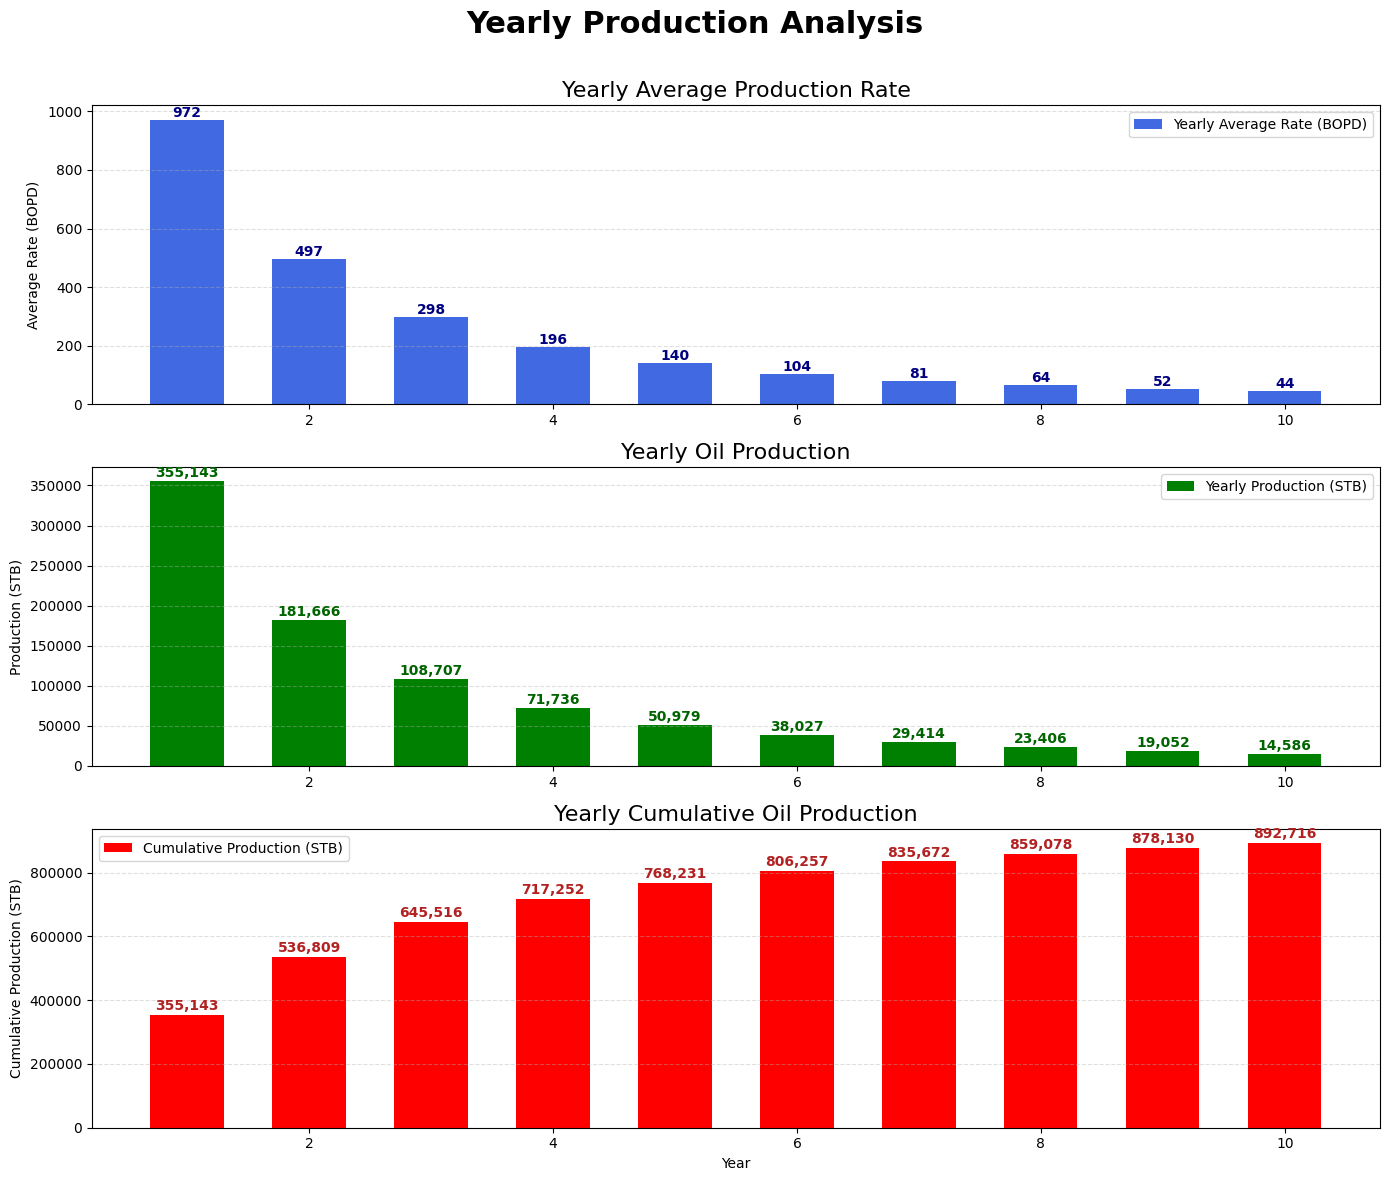

In [50]:
# Figure
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Yearly Production Analysis", fontsize=22, fontweight="bold")

# -----------------------------
# 1. Yearly Average Production Rate
# -----------------------------
axes[0].bar(
    yearly_summary.index,
    yearly_summary["Average_Oil_Rate"],
    color="royalblue",
    width=0.6,
    label="Yearly Average Rate (BOPD)"
)

axes[0].set_title("Yearly Average Production Rate", fontsize=16)
axes[0].set_ylabel("Average Rate (BOPD)")
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].legend()

for i, value in enumerate(yearly_summary["Average_Oil_Rate"]):
    axes[0].text(
        yearly_summary.index[i],
        value + 10,
        f"{value:.0f}",
        ha='center',
        color='navy',
        fontsize=10,
        fontweight='bold'
    )

# -----------------------------
# 2. Yearly Oil Production
# -----------------------------
axes[1].bar(
    yearly_summary.index,
    yearly_summary["Yearly_Production"],
    color="green",
    width=0.6,
    label="Yearly Production (STB)"
)

axes[1].set_title("Yearly Oil Production", fontsize=16)
axes[1].set_ylabel("Production (STB)")
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].legend()

for i, value in enumerate(yearly_summary["Yearly_Production"]):
    axes[1].text(
        yearly_summary.index[i],
        value + 5000,
        f"{value:,.0f}",
        ha='center',
        color='darkgreen',
        fontsize=10,
        fontweight='bold'
    )

# -----------------------------
# 3. Yearly Cumulative Production
# -----------------------------
axes[2].bar(
    yearly_summary.index,
    yearly_summary["Yearly_Cumulative_Production"],
    color="red",
    width=0.6,
    label="Cumulative Production (STB)"
)

axes[2].set_title("Yearly Cumulative Oil Production", fontsize=16)
axes[2].set_ylabel("Cumulative Production (STB)")
axes[2].set_xlabel("Year")
axes[2].grid(axis='y', linestyle='--', alpha=0.4)
axes[2].legend()

for i, value in enumerate(yearly_summary["Yearly_Cumulative_Production"]):
    axes[2].text(
        yearly_summary.index[i],
        value + 15000,
        f"{value:,.0f}",
        ha='center',
        color='firebrick',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()
